C:\Users\mikel\AppData\Local\Temp\ipykernel_27372\2549749016.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')


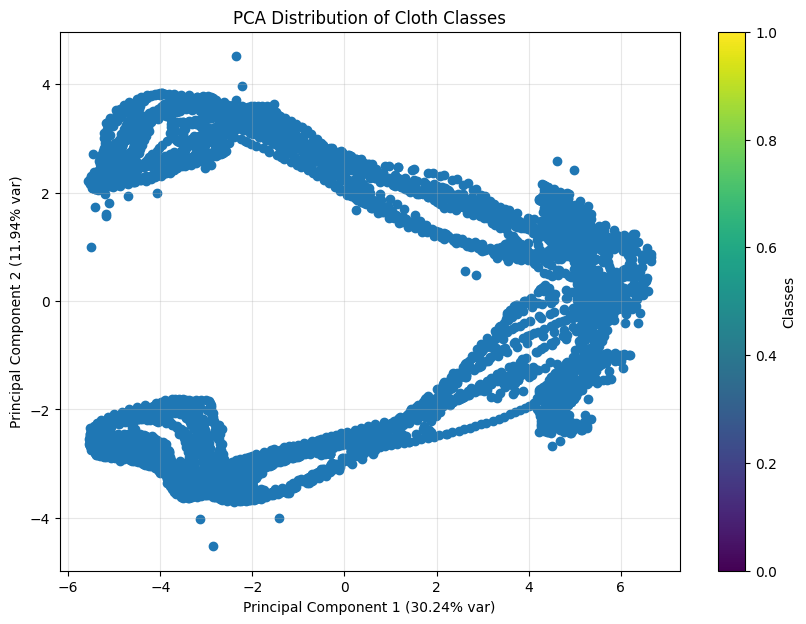

In [ ]:
#Importación de funciones de los diferentes archivos
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import matplotlib.pyplot as plt

# Guardo todos los datos
df = pd.read_csv('data/clothDataset_35_.csv') 

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 6. Visualizationplt.figure(figsize=(10, 7))
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')
plt.title('PCA Distribution of Cloth Classes')
plt.title('PCA Distribution of Cloth Classes')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} var)')
plt.colorbar(scatter, label='Classes')
plt.grid(True, alpha=0.3)


plt.show()

C:\Users\mikel\AppData\Local\Temp\ipykernel_20772\1557002587.py:24: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], cmap='viridis')


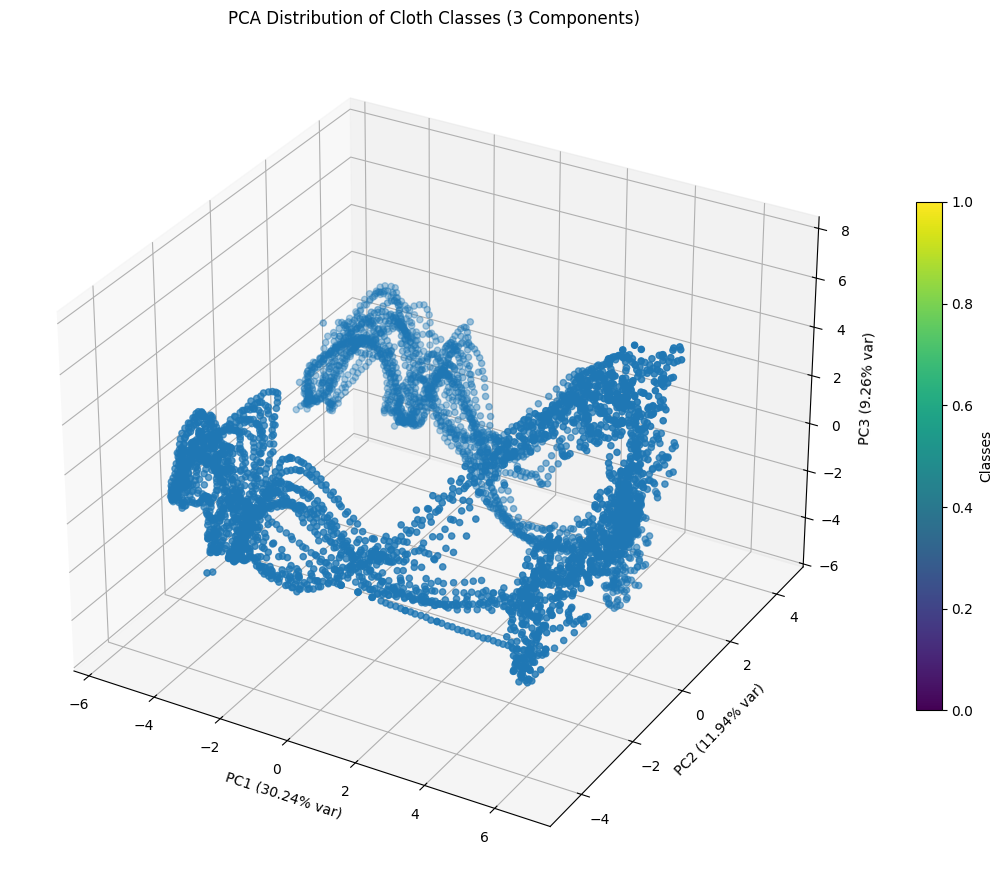

Varianza total explicada: 51.44%


In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Cargar datos
df = pd.read_csv('data/clothDataset_35_.csv') 
X = df

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplicar PCA con 3 componentes
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Visualización 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], cmap='viridis')

ax.set_title('PCA Distribution of Cloth Classes (3 Components)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} var)')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.2%} var)')

plt.colorbar(scatter, label='Classes', shrink=0.6)
plt.tight_layout()
plt.show()

# Varianza total explicada
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.2%}")


Optimal number of components (95% variance): 14
Variance explained: 95.06%


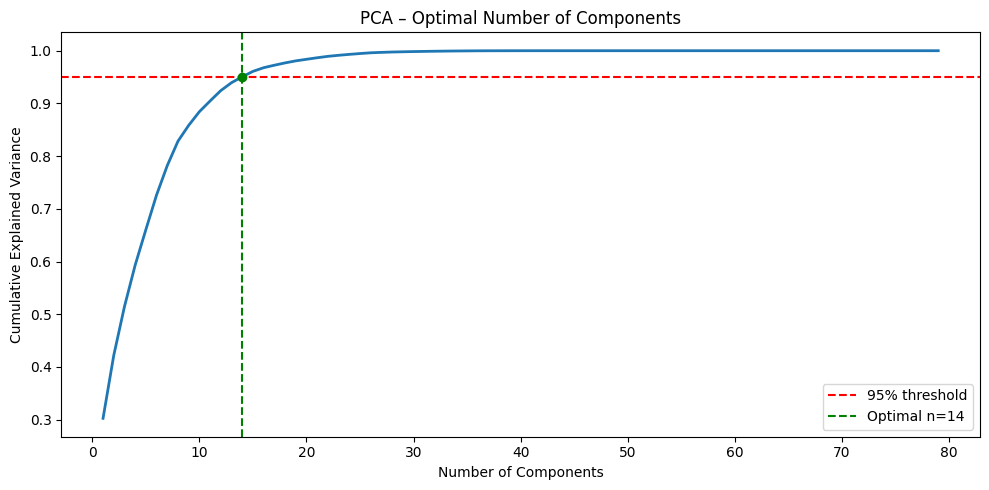


Reduced shape: (5000, 14)
Total variance explained: 95.06%


In [3]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('data/clothDataset_35_.csv')
X = df

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Step 1: Find optimal n_components ---
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = pca_full.explained_variance_ratio_.cumsum()
optimal_n = np.argmax(cumulative_variance >= 0.95) + 1  # +1 because 0-indexed

print(f"Optimal number of components (95% variance): {optimal_n}")
print(f"Variance explained: {cumulative_variance[optimal_n - 1]:.2%}")

# --- Step 2: Plot the variance curve with the optimal point marked ---
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.axvline(x=optimal_n, color='g', linestyle='--', label=f'Optimal n={optimal_n}')
plt.scatter([optimal_n], [cumulative_variance[optimal_n - 1]], color='g', zorder=5)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Optimal Number of Components')
plt.legend()
plt.tight_layout()
plt.show()

# --- Step 3: Apply PCA with optimal n_components ---
pca = PCA(n_components=optimal_n)
X_pca = pca.fit_transform(X_scaled)

print(f"\nReduced shape: {X_pca.shape}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

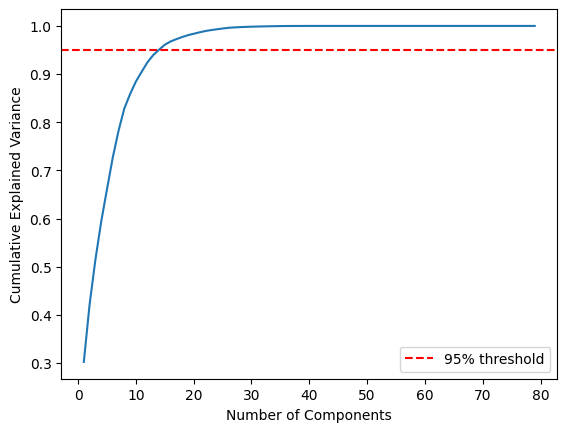

In [2]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv('data/clothDataset_35_.csv') 
X = df

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

cumulative_variance = pca.explained_variance_ratio_.cumsum()

plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.show()

In [6]:
#ADAPTAR DATAFRAME PARA EL RNN
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Cargar el dataset
csv_path = 'data/clothDataset_35_.csv' # Asegúrate de que la ruta sea correcta
df = pd.read_csv(csv_path)

# cargamos los merged
#df = cloth_info

# 2. Seleccionar SOLO las columnas que queremos en el orden correcto
# Queremos: x0, y0, z0, sdf0, x1, y1, z1, sdf1...
selected_columns = []
for i in range(6): # Para los 6 vértices
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', f'sdf{i}'])

# Filtramos el DataFrame
df_filtered = df[selected_columns]

# 3. Extraer valores y hacer reshape a 3D
data_flat = df_filtered.values
num_frames = data_flat.shape[0]
num_vertices = 6
num_features = 4

# 4. Reestructurar (Reshape) a 3D
# Numpy reorganiza los 78 valores de cada fila en una cuadrícula de 6x13
data_3d = data_flat.reshape((num_frames, num_vertices, num_features))

# 5. Convertir a Tensor de PyTorch
data_tensor = torch.tensor(data_3d, dtype=torch.float32)

print(f"Forma de los datos aplanados: {data_flat.shape}")
print(f"Forma del Tensor 3D final: {data_tensor.shape}")
# Salida esperada: 
# Forma de los datos aplanados: (966, 78)
# Forma del Tensor 3D final: torch.Size([966, 6, 13])

Forma de los datos aplanados: (5000, 24)
Forma del Tensor 3D final: torch.Size([5000, 6, 4])


In [7]:
class ClothSequenceDataset(Dataset):
    def __init__(self, data_frames, seq_len=5):
        """
        Argumentos:
        data_frames: Tensor o arreglo de NumPy con todos tus frames en orden secuencial.
                     Forma esperada: [Total_Frames, Vertices, Features]
        seq_len: La cantidad de frames "históricos" que la red usará para predecir el siguiente.
        """
        # Convertimos a tensor si aún no lo es
        if not isinstance(data_frames, torch.Tensor):
            self.data_frames = torch.tensor(data_frames, dtype=torch.float32)
        else:
            self.data_frames = data_frames
            
        self.seq_len = seq_len

    def __len__(self):
        # La longitud total es el número de frames menos el tamaño de la secuencia.
        # ¿Por qué? Si tienes 100 frames y secuencias de 5, el último bloque que 
        # puedes formar es del frame 94 al 98, para predecir el frame 99.
        return len(self.data_frames) - self.seq_len

    def __getitem__(self, idx):
        # Extraemos la secuencia histórica (ventana temporal)
        # Forma: [Seq_Len, Vertices, Features]
        sequence = self.data_frames[idx : idx + self.seq_len]
        
        # El "target" es el frame inmediatamente posterior a la secuencia
        # Forma: [Vertices, Features]
        target_frame = self.data_frames[idx + self.seq_len]
        
        return sequence, target_frame

# --- Example Usage ---
# --- Parámetros de la secuencia ---
seq_length = 5 # La RNN mirará 5 frames atrás
batch_size = 32

# Instanciar el Dataset
dataset = ClothSequenceDataset(data_tensor, seq_len=seq_length)

# Crear el DataLoader
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Comprobar el primer Batch
for batch_seq, batch_target in train_loader:
    print(f"\nBatch Secuencia (Entrada RNN): {batch_seq.shape}") 
    # Esperado: [32, 5, 6, 13] -> [Batch, Secuencia, Vértices, Features]
    
    print(f"Batch Objetivo (Target): {batch_target.shape}")   
    # Esperado: [32, 6, 13] -> [Batch, Vértices, Features]
    break


Batch Secuencia (Entrada RNN): torch.Size([32, 5, 6, 4])
Batch Objetivo (Target): torch.Size([32, 6, 4])


In [8]:
import torch
import torch.nn as nn

class FlatRNNClothUnity(nn.Module):
    def __init__(self, num_vertices, num_features, hidden_size, num_outputs=3):
        super(FlatRNNClothUnity, self).__init__()
        
        self.num_vertices = num_vertices
        self.num_outputs = num_outputs
        
        self.input_size = num_vertices * num_features 
        self.hidden_size = hidden_size
        
        # 1. CAMBIO: Usamos RNNCell en lugar de RNN
        # Un "Cell" procesa un solo frame a la vez. No usa batch_first.
        self.rnn_cell = nn.RNNCell(input_size=self.input_size, 
                                   hidden_size=self.hidden_size, 
                                   nonlinearity='relu') 
        
        self.fc = nn.Linear(self.hidden_size, num_vertices * num_outputs)

    def forward(self, x):
        # Forma esperada de x: [Batch, Sequence_Length, Vertices, Features]
        batch_size = x.size(0)
        seq_len = x.size(1)
        
        # Aplanar el espacio: [Batch, Seq_Len, Vertices * Features]
        x_flat = x.view(batch_size, seq_len, -1)
        
        # 2. CAMBIO: Inicializamos el estado oculto (memoria de la red) a ceros
        h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        
        # 3. CAMBIO: Bucle manual a través de la secuencia temporal (5 frames)
        for t in range(seq_len):
            # Le pasamos el frame actual y la memoria del frame anterior
            h_t = self.rnn_cell(x_flat[:, t, :], h_t)
            
        # Al terminar el bucle, 'h_t' contiene la información del ÚLTIMO frame (el frame 5)
        # Esto evita tener que hacer el slice out[:, -1, :] que rompía Unity
        
        # Pasar por la capa lineal
        pred_flat = self.fc(h_t) 
        
        # Restaurar a 3D
        pred_delta = pred_flat.view(batch_size, self.num_vertices, self.num_outputs)
        
        return pred_delta

In [10]:
import torch
from torch.utils.data import random_split, DataLoader
import json

# ==============================================================================
# 1. SPLIT THE DATA (80% Training, 20% Testing)
# ==============================================================================
"""
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

#TODO: vigilar esto!!!
# Nota: Al usar random_split, mezclamos secuencias de 5 frames de forma aleatoria.
# Esto suele funcionar bien, aunque para algunos problemas físicos puristas a veces 
# se divide cronológicamente (ej. primeros 80% frames para train, últimos 20% para test).
# Por ahora mantendremos random_split que es el enfoque estándar general.
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
"""

train_dataset, test_dataset = dataset, dataset

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ==============================================================================
# 2. COMPUTE GLOBAL STATS (Only on training data to prevent data leakage)
# ==============================================================================
all_inputs = []
all_targets = []

# Iteramos sobre el TRAIN LOADER específicamente
for batch_seq, batch_target in train_loader:
    # batch_seq shape: [Batch, Seq_Len, Vertices, Features (4)]
    # Aplanamos para agrupar todas las características y calcular medias por Feature
    # Nueva forma temporal: (Batch * Seq_Len * Vertices, 4)
    all_inputs.append(batch_seq.view(-1, 4))
    
    # Calcular el target (Desplazamiento / Delta)
    # 1. Extraemos las posiciones x, y, z (índices 0:3) del ÚLTIMO frame de la secuencia
    last_frame_pos = batch_seq[:, -1, :, 0:3] 
    
    # 2. Restamos la posición del frame objetivo para sacar el delta
    # batch_target shape: [Batch, Vertices, Features (4)]
    delta = batch_target[:, :, 0:3] - last_frame_pos
    
    # Guardamos los deltas aplanados: (Batch * Vertices, 3)
    all_targets.append(delta.view(-1, 3))

# Combinar todas las listas en un solo tensor gigante
full_input_tensor = torch.cat(all_inputs, dim=0)
full_target_tensor = torch.cat(all_targets, dim=0)

# Calcular las estadísticas globales (mean y std a lo largo de la columna)
input_mean = full_input_tensor.mean(dim=0)
input_std = full_input_tensor.std(dim=0)
target_mean = full_target_tensor.mean(dim=0)
target_std = full_target_tensor.std(dim=0)

print("Forma de input_mean:", input_mean.shape) # Debería ser [13]
print("Forma de target_mean:", target_mean.shape) # Debería ser [3]

# ==============================================================================
# 3. SAVE TO JSON
# ==============================================================================
norm_data = {
    "mean": input_mean.tolist(),
    "std": input_std.tolist(),
    "target_mean": target_mean.tolist(),
    "target_std": target_std.tolist()
}
with open("cloth_norm_params.json", "w") as f:
    json.dump(norm_data, f)

# ==============================================================================
# 4. SETUP MODEL
# ==============================================================================
model = FlatRNNClothUnity(num_vertices=6, num_features=4, hidden_size=128, num_outputs=3)
criterion = nn.L1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

# ==============================================================================
# 5. TRAINING & TESTING LOOP
# ==============================================================================
epochs = 100
for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() 
    noise_scale = 0.02
    train_loss = 0.0
    
    for batch_seq_t, batch_target in train_loader:
        batch_seq_t = batch_seq_t.float()  
        batch_target = batch_target.float() 
        
        # 1. Normalizar toda la secuencia de entrada 
        batch_seq_t_norm = (batch_seq_t - input_mean) / input_std
        
        # Creamos un ruido Gaussiano con la misma forma que nuestra entrada
        noise = torch.randn_like(batch_seq_t_norm) * noise_scale
        
        # Le sumamos el ruido al input histórico
        batch_seq_t_norm += noise

        # 2. Target Delta
        last_frame_positions = batch_seq_t[:, -1, :, 0:3] 
        target_delta = batch_target[..., 0:3] - last_frame_positions
        target_delta_norm = (target_delta - target_mean) / target_std
        
        # 3. Predicción
        pred_delta_norm = model(batch_seq_t_norm)
        
        # 4. Retropropagación
        loss = criterion(pred_delta_norm, target_delta_norm)
    
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()

    print(f'Train Epoch {epoch+1:03d}')

    avg_train_loss = train_loss / len(train_loader)

    # --- TESTING/VALIDATION PHASE ---
    model.eval() 
    test_loss = 0.0
    total_distance_error = 0.0
    total_vertices = 0

    all_pred_deltas = []
    all_target_deltas = []
    all_pred_pos = []
    all_target_pos = []
    
    with torch.no_grad():
        # CORRECCIÓN: Usamos batch_seq_t y batch_target igual que en train
        for batch_seq_t, batch_target in test_loader:
            batch_seq_t = batch_seq_t.float()
            batch_target = batch_target.float()

            batch_seq_t_norm = (batch_seq_t - input_mean) / input_std
            
            pred_delta_norm = model(batch_seq_t_norm)
            
            # CORRECCIÓN: Extraemos posiciones del último frame de la secuencia
            last_frame_positions = batch_seq_t[:, -1, :, 0:3] 
            
            # Target delta (Posición real del siguiente frame - Posición del último frame)
            target_delta = batch_target[..., 0:3] - last_frame_positions
            target_delta_norm = (target_delta - target_mean) / target_std

            loss = criterion(pred_delta_norm, target_delta_norm)
            test_loss += loss.item()

            # --- Reconstruct the absolute positions ---
            pred_delta_real = (pred_delta_norm * target_std) + target_mean
            pred_pos = last_frame_positions + pred_delta_real
            target_pos = batch_target[..., 0:3] # The true final position

            # Store them
            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())
            
            # Calculate our "Accuracy" (Mean Distance Error per vertex)
            distances = torch.norm(pred_delta_real - target_delta, dim=-1)
            total_distance_error += distances.sum().item()
            total_vertices += distances.numel()

            # Store the data for PCA
            all_pred_deltas.append(pred_delta_real.cpu().numpy())
            all_target_deltas.append(target_delta.cpu().numpy())

    avg_test_loss = test_loss / len(test_loader)
    avg_distance_error = total_distance_error / total_vertices

    # Combine into large arrays
    preds_pos_np = np.concatenate(all_pred_pos, axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    print(f'Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f} | Avg Vertex Error: {avg_distance_error:.6f} units')

Forma de input_mean: torch.Size([4])
Forma de target_mean: torch.Size([3])
Train Epoch 001
Epoch 001 | Train Loss: 0.575017 | Test Loss: 0.561191 | Avg Vertex Error: 0.012376 units
Train Epoch 002
Epoch 002 | Train Loss: 0.559876 | Test Loss: 0.558356 | Avg Vertex Error: 0.012323 units
Train Epoch 003
Epoch 003 | Train Loss: 0.558048 | Test Loss: 0.557015 | Avg Vertex Error: 0.012294 units
Train Epoch 004
Epoch 004 | Train Loss: 0.556944 | Test Loss: 0.556057 | Avg Vertex Error: 0.012272 units
Train Epoch 005
Epoch 005 | Train Loss: 0.556106 | Test Loss: 0.555380 | Avg Vertex Error: 0.012245 units
Train Epoch 006
Epoch 006 | Train Loss: 0.555217 | Test Loss: 0.554523 | Avg Vertex Error: 0.012226 units
Train Epoch 007
Epoch 007 | Train Loss: 0.554212 | Test Loss: 0.553221 | Avg Vertex Error: 0.012191 units
Train Epoch 008
Epoch 008 | Train Loss: 0.553112 | Test Loss: 0.551846 | Avg Vertex Error: 0.012152 units
Train Epoch 009
Epoch 009 | Train Loss: 0.551823 | Test Loss: 0.550402 | Avg 

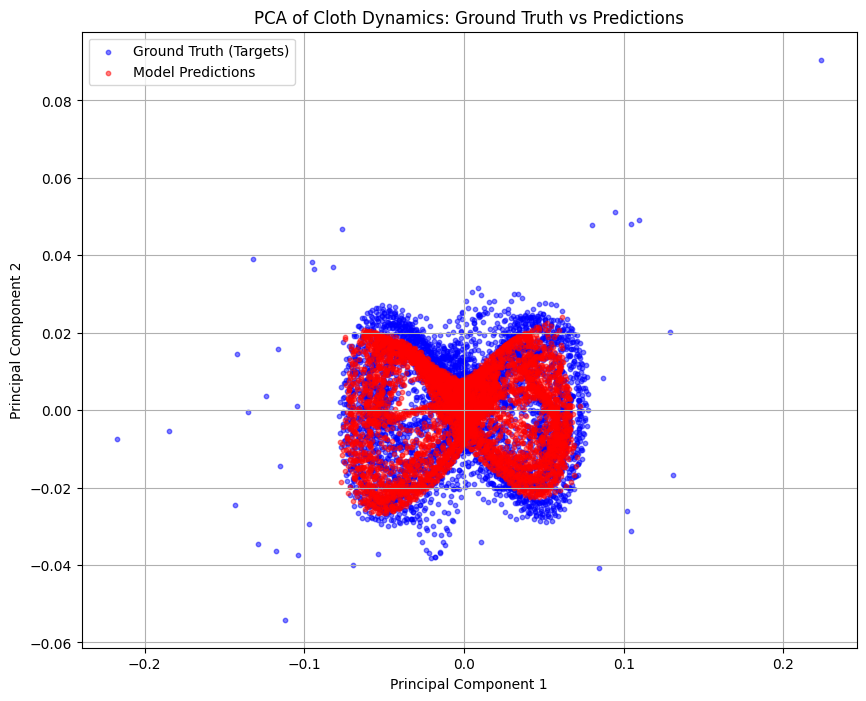

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Combine the collected batches into single large arrays
preds_np = np.concatenate(all_pred_deltas, axis=0)     # Shape: (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # Shape: (Total_Frames, Vertices, 3)

# 2. Reshape to 2D: (Total_Frames, Vertices * 3)
preds_2d = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# 3. Initialize PCA
pca = PCA(n_components=2) # 2 components for a 2D scatter plot

# CRITICAL: Fit the PCA on the TARGETS (Ground Truth) to define the coordinate space.
# If you fit two separate PCAs, the axes will mean different things and you cannot compare them!
pca.fit(targets_2d)

# Transform both datasets into this shared PCA space
pca_targets = pca.transform(targets_2d)
pca_preds = pca.transform(preds_2d)

# 4. Plot the comparison
plt.figure(figsize=(10, 8))

# Plot ground truth in blue
plt.scatter(pca_targets[:, 0], pca_targets[:, 1], alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)

# Plot predictions in red
plt.scatter(pca_preds[:, 0], pca_preds[:, 1], alpha=0.5, label='Model Predictions', color='red', s=10)

plt.title('PCA of Cloth Dynamics: Ground Truth vs Predictions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

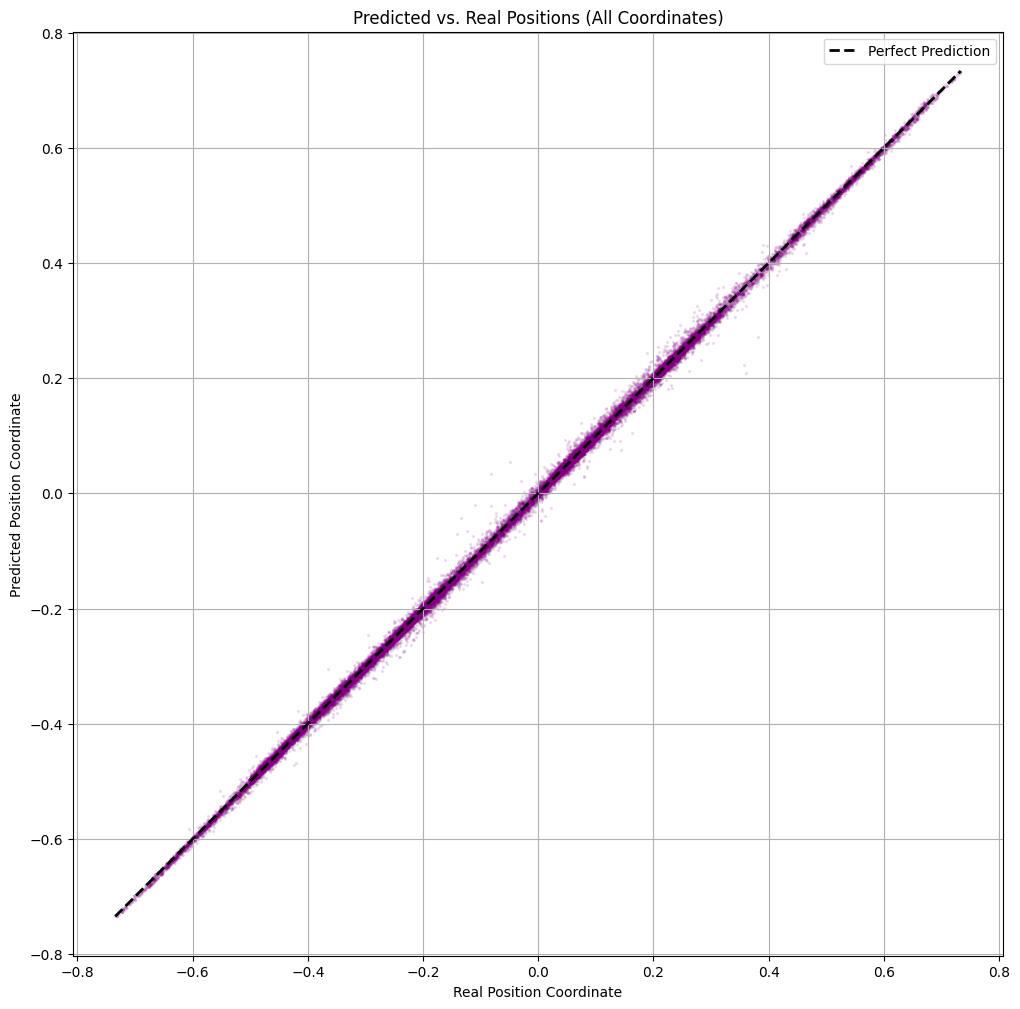

In [12]:
import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(12, 12))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

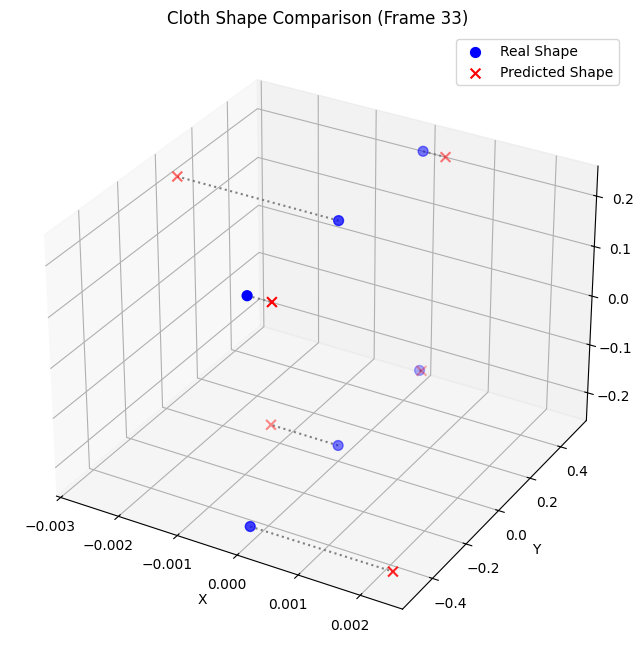

In [13]:
# Choose a random frame from your test set to visualize
frame_idx = 33 # Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [14]:
import torch
import sys
import onnx
import onnxruntime

# 1. Load your trained model (make sure it's in eval mode)
model.eval()

# 2. NUEVO: Creamos el dummy input con 4 dimensiones: 
# [Batch=1, Seq_Len=5, Vertices=6, Features=4]
dummy_input = torch.randn(1, 5, 6, 4)

# 3. Export to ONNX (el resto se mantiene igual)
onnx_program = torch.onnx.export(
    model,                      
    dummy_input,                # Tu [1, 5, 6, 4]
    "cloth_BIG_rnn.onnx", 
    export_params=True,         
    opset_version=15,           # <--- Subir a 15
    input_names=['input'],      
    output_names=['output'],    
)

print("Exported to ONNX with strict 4D sequential shapes!")

Exported to ONNX with strict 4D sequential shapes!
